# Variance Gamma Option Pricing via Carr-Madan FFT

Calibration of the Variance Gamma (VG) model to SPX implied volatility surface 
using the Carr-Madan FFT pricing framework. Market data sourced from Yahoo Finance.

## 1. FFT Pricing Engine
Implementation of the Carr-Madan (1999) algorithm. The VG characteristic function 
is used to price calls across a log-strike grid via FFT.

Using the formula: 
$$
C(k_u) = \frac{\exp(-\alpha k_u)}{\pi}FFT(x(j)), \quad x(j)=e^{ib \nu_j}\psi(\nu_j)\frac{\eta}{3}[3+(-1)^j-\delta_{j-1}]
$$
The Simpson's rule weights $\frac{\eta}{3}[3+(-1)^j - \delta_{j-1}]$ are applied to improve the accuracy of the numerical integration over the trapezoidal rule.

Using the definition of the FFT:
$$
w(k)=\sum_{j=1}^N e^{-i\frac{2\pi}{N}(j-1)(k-1)}x(j), \quad \text{for } k=1,2,...,N
$$

And knowing:
$$
\psi_T(\nu)=\frac{e^{-rT}\phi_T(\nu-(\alpha+1)i)}{\alpha^2+\alpha-\nu^2+i(2\alpha+1)\nu}
$$

where $\phi_T(u)$ is the characteristic function and is supposed to be known analatically. For the Black-Scholes-Merton model we have 
$$
\phi_{BSM}(u)=\exp(iu[\log S_0 +(r-\frac{1}{2}\sigma^2)T]-\frac{1}{2}\sigma^2u^2T)
$$

In the VG model we have:
$$
\phi_{VG}(u)=\exp(iu[\log S_0 + (r+w)T])[1-i\theta\nu u + \frac{1}{2}\sigma^2u^2\nu]^{-\frac{T}{\nu}}
$$
where we set $w=\frac{1}{\nu}\log(1-\theta\nu-\frac{1}{2}\sigma^2\nu)$ so that the mean return of the stock is equal to the risk free-rate $r$.

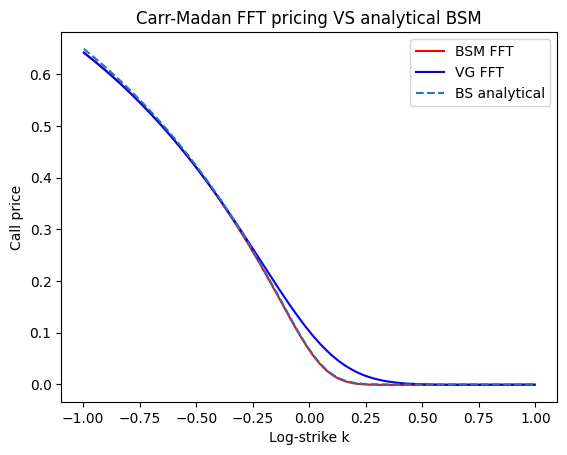

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd

N = 8192
eta = 0.05
alpha = 1.5

def C_ITM(r, T, N, S_0, params, eta, alpha, phi):
    lambda_1 = (2*np.pi)/(N*eta)
    b = 0.5 * N * lambda_1
    k = np.array([-b + lambda_1*(u - 1) for u in range(1,N+1)])
    nu = np.array([eta*(j-1) for j in range(1, N+1)])
    weights = (3 + (-1)**np.arange(N)).astype(float)
    weights[0] = 1
    weights[-1] = 1

    psi = ((np.exp(-r*T))*phi(r, T, S_0, params, nu - (alpha + 1)*1j))/(alpha**2 + alpha - nu**2 + 1j*(2*alpha + 1)*nu)
    x = np.exp(1j*b*nu)*psi*(eta/3) * weights
    return k, (np.exp(-alpha * k)/np.pi) * np.real(np.fft.fft(x))

#Test VG

S_0 = 1
params_VG = [-0.1, 0.2, 0.1]
# theta = -0.1
# sigma = 0.2
# v = 0.1

def phi_VG(r, T, S_0, params, u):
    theta, sigma, v = params
    omega = (1/v)*np.log(1 - theta * v - 0.5 * sigma**2 * v)
    return np.exp(1j*u*(np.log(S_0) + (r+omega)*T))*(1 - 1j * theta*v*u + 0.5 * sigma**2 * u**2 * v)**(-T/v)

k, C = C_ITM(0.05, 1, N, S_0, params_VG, eta, alpha, phi_VG)

mask = (k >= -1) & (k <= 1)

#Test BSM

def phi_BSM(r, T, S_0, params, u):
    sigma, = params
    return np.exp(1j*u*(np.log(S_0) + (r - 0.5*sigma**2)*T) - 0.5*sigma**2*u**2*T)

params_BSM = [0.1]

k_BSM, C_BSM = C_ITM(0.05, 1, N, S_0, params_BSM, eta, alpha, phi_BSM)

def BS_call(S0, K, r, T, sigma):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

BS_prices = BS_call(S_0, np.exp(k[mask]), 0.05, 1, params_BSM[0])
plt.plot(k_BSM[mask], C_BSM[mask], label='BSM FFT', color = 'red')
plt.plot(k[mask], C[mask], label='VG FFT', color = 'blue')
plt.plot(k_BSM[mask], BS_prices, label='BS analytical', linestyle='--')
plt.xlabel('Log-strike k')
plt.ylabel('Call price')
plt.title('Carr-Madan FFT pricing VS analytical BSM')
plt.legend()
plt.show()



## 2. Market Data
SPX option chain for 3 maturities (24d, 53d, 81d). Risk-free rate from 3-month T-bill. 
IV extracted by inverting BSM numerically (Brent method).

In [2]:
import yfinance as yf
from datetime import datetime

ticker = yf.Ticker("^SPX")
df = ticker.option_chain('2026-06-25').calls
S = yf.Ticker("^SPX").history(period="1d")["Close"].iloc[-1]
tbill = yf.Ticker("^IRX")
r = tbill.history(period="1d")["Close"].iloc[-1] / 100
print(r)

df_filtered = df[(df['bid']>0) & (df['strike']/S > 0.9) & (df['strike']/S < 1.10) ]
df_filtered['mid_price'] = (df_filtered['ask'] + df_filtered['bid'])/2
df_filtered.head()

0.03625


C:\Users\victo\AppData\Local\Temp\ipykernel_13056\2248050544.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['mid_price'] = (df_filtered['ask'] + df_filtered['bid'])/2


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,mid_price
3,SPXW260625C06725000,2026-06-01 18:47:58+00:00,6725.0,905.63,652.3,676.3,0.0,0.0,2.0,0,0.286308,True,REGULAR,USD,664.3
4,SPXW260625C06850000,2026-05-12 15:24:30+00:00,6850.0,562.91,533.8,557.8,0.0,0.0,NaN,5,0.264267,True,REGULAR,USD,545.8
5,SPXW260625C06875000,2026-05-12 15:24:30+00:00,6875.0,540.65,510.5,534.5,0.0,0.0,NaN,5,0.260082,True,REGULAR,USD,522.5
6,SPXW260625C06900000,2026-05-27 13:30:04+00:00,6900.0,656.77,487.3,511.3,0.0,0.0,2.0,3,0.255783,True,REGULAR,USD,499.3
7,SPXW260625C06975000,2026-05-29 18:51:26+00:00,6975.0,623.77,418.8,442.8,0.0,0.0,1.0,1,0.243248,True,REGULAR,USD,430.8


## Market Data & IV Extraction

SPX option chains are fetched for 3 maturities via `yfinance`. We filter to liquid 
strikes only (`bid > 0`, `|log(K/S)| < 0.05`) and compute mid-prices.

Implied volatility is extracted by numerically inverting the BSM formula for each 
strike using Brent's method:

$$\sigma^*_i = \text{arg} \{ C_{BSM}(S, K_i, r, T, \sigma) = C^{mid}_i \}$$

Prices are normalized by spot $S$ throughout (i.e. $S_0 = 1$) to avoid numerical 
scaling issues in the FFT pricing step.

30d → 2026-07-06 (T=0.0849)
60d → 2026-07-31 (T=0.1534)
90d → 2026-08-31 (T=0.2384)


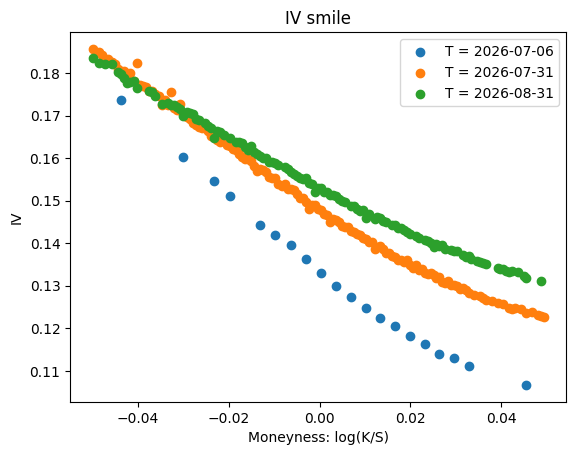

In [3]:
from datetime import datetime, timedelta

today = datetime.today()
target_30 = today + timedelta(days=30)
target_60 = today + timedelta(days=60)
target_90 = today + timedelta(days=90)

expirations = ticker.options
expirations_dt = [datetime.strptime(e, '%Y-%m-%d') for e in expirations]

# Finding the nearest maturity for each target date
def nearest_expiry(target, expirations_dt, expirations):
    idx = min(range(len(expirations_dt)), key=lambda i: abs((expirations_dt[i] - target).days))
    return expirations[idx], expirations_dt[idx]

exp_30, dt_30 = nearest_expiry(target_30, expirations_dt, expirations)
exp_60, dt_60 = nearest_expiry(target_60, expirations_dt, expirations)
exp_90, dt_90 = nearest_expiry(target_90, expirations_dt, expirations)

T_30d = (dt_30 - today).days / 365
T_60d = (dt_60 - today).days / 365
T_90d = (dt_90 - today).days / 365

print(f"30d → {exp_30} (T={T_30d:.4f})")
print(f"60d → {exp_60} (T={T_60d:.4f})")
print(f"90d → {exp_90} (T={T_90d:.4f})")


from scipy.optimize import brentq

def get_iv(row, T_i):
    K = row["strike"] / S
    mid = row["mid_price"] / S
    try:
        iv = brentq(lambda sigma: BS_call(1, K, r, T_i, sigma) - mid, 1e-6, 5.0)
        return iv
    except:
        return np.nan


df_30d = ticker.option_chain(exp_30).calls
df_60d = ticker.option_chain(exp_60).calls
df_90d = ticker.option_chain(exp_90).calls
S = yf.Ticker("^SPX").history(period="1d")["Close"].iloc[-1]

df_filtered_30d = df_30d[(df_30d['bid']>0) & (df_30d['strike']/S > 0.9) & (df_30d['strike']/S < 1.10) & (np.log(df_30d['strike']/S) > -0.05) & (np.log(df_30d['strike']/S) < 0.05)].copy()
df_filtered_60d = df_60d[(df_60d['bid']>0) & (df_60d['strike']/S > 0.9) & (df_60d['strike']/S < 1.10) & (np.log(df_60d['strike']/S) > -0.05) & (np.log(df_60d['strike']/S) < 0.05)].copy()
df_filtered_90d = df_90d[(df_90d['bid']>0) & (df_90d['strike']/S > 0.9) & (df_90d['strike']/S < 1.10) & (np.log(df_90d['strike']/S) > -0.05) & (np.log(df_90d['strike']/S) < 0.05)].copy()

df_filtered_30d['mid_price'] = (df_filtered_30d['ask'] + df_filtered_30d['bid'])/2
df_filtered_60d['mid_price'] = (df_filtered_60d['ask'] + df_filtered_60d['bid'])/2
df_filtered_90d['mid_price'] = (df_filtered_90d['ask'] + df_filtered_90d['bid'])/2

df_filtered_30d['iv_market'] = df_filtered_30d.apply(lambda row: get_iv(row, T_30d), axis=1)
df_filtered_60d['iv_market'] = df_filtered_60d.apply(lambda row: get_iv(row, T_60d), axis=1)
df_filtered_90d['iv_market'] = df_filtered_90d.apply(lambda row: get_iv(row, T_90d), axis=1)

df_filtered_30d['log(K/S)'] = np.log(df_filtered_30d['strike']/S)
df_filtered_60d['log(K/S)'] = np.log(df_filtered_60d['strike']/S)
df_filtered_90d['log(K/S)'] = np.log(df_filtered_90d['strike']/S)

plt.scatter(df_filtered_30d['log(K/S)'], df_filtered_30d['iv_market'], label = f'T = {exp_30}')
plt.scatter(df_filtered_60d['log(K/S)'], df_filtered_60d['iv_market'], label = f'T = {exp_60}')
plt.scatter(df_filtered_90d['log(K/S)'], df_filtered_90d['iv_market'], label = f'T = {exp_90}')
plt.legend()
plt.xlabel('Moneyness: log(K/S)')
plt.ylabel('IV')
plt.title('IV smile')
plt.show()


## SPX Implied Volatility Surface

Market IV extracted from SPX option mid-prices across 3 maturities (24d, 53d, 81d).

Two stylized facts are immediately visible:

**Negative skew** — IV decreases monotonically with strike for all maturities. 
This reflects the persistent demand for OTM puts as portfolio hedges, a structural 
feature of equity index options absent in single stocks or crypto.

**Normal term structure** — IV increases with maturity at all strikes. 
Short-dated options are cheaper in IV terms, consistent with a low-volatility 
regime (VIX ~15 at time of data collection).

Note the absence of a symmetric smile: the VG model, which can generate both 
skew and kurtosis, will be primarily constrained by the skew parameter θ here.

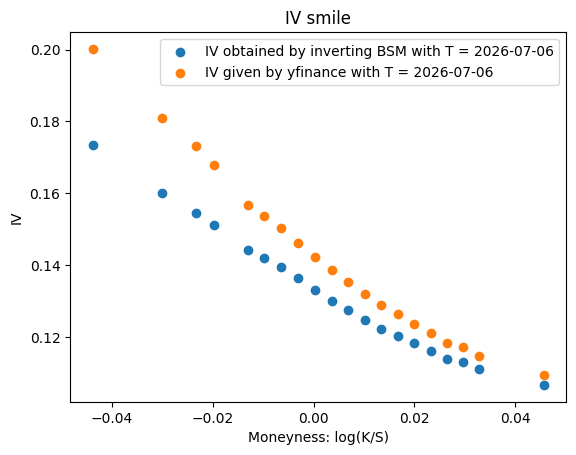

In [4]:
plt.scatter(df_filtered_30d['log(K/S)'], df_filtered_30d['iv_market'], label = f'IV obtained by inverting BSM with T = {exp_30}')
plt.scatter(df_filtered_30d['log(K/S)'], df_filtered_30d['impliedVolatility'], label = f'IV given by yfinance with T = {exp_30}')
plt.legend()
plt.xlabel('Moneyness: log(K/S)')
plt.ylabel('IV')
plt.title('IV smile')
plt.show()

## Sanity Check: BSM IV vs yfinance implied volatility

We compare our BSM-inverted IV against the implied volatility provided directly 
by yfinance. The two series diverge significantly for OTM puts (deep negative moneyness), 
which suggests that yfinance uses a different convention — likely calendar days vs 
trading days for T, or a different risk-free rate. 

For ATM and OTM calls (log(K/S) > -0.01), both series converge, giving us confidence 
that our IV extraction is correct in the liquid part of the smile. We use our 
BSM-inverted IV throughout, as it gives full control over the inputs (r, T, S).

## 3. VG Calibration
Per-maturity calibration minimizing IV RMSE. L-BFGS-B optimizer with multiple starting points to avoid local minima.

**Parallelisation**

Each starting point in `x0_candidates` leads to an independent optimisation problem. We parallelise across starting points using `joblib`, then retain the solution with the lowest RMSE. For the future historical backtest, parallelisation will be instead done across trading days, each day being an independent calibration problem.

0.07671232876712329 [-0.23868327  0.15442827  0.1055081 ] 0.0018954998225486916
0.15616438356164383 [-0.16371913  0.16267624  0.23612605] 0.001490168358447343
0.2410958904109589 [-0.12275776  0.17065976  0.38318422] 0.0009308937653187838


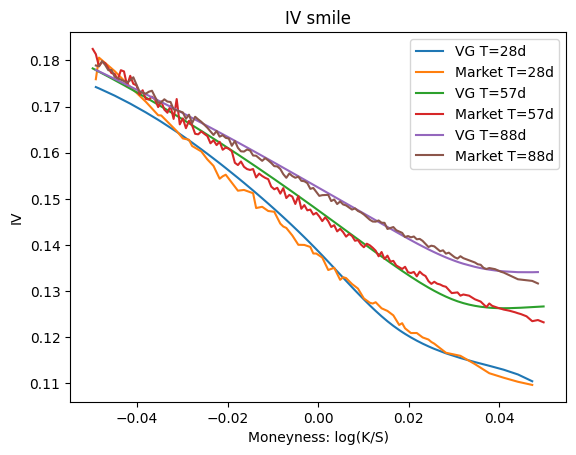

In [7]:
from scipy.optimize import minimize, brentq
from scipy.interpolate import CubicSpline

T = [T_30d, T_60d, T_90d]
df_filtered_tot = [df_filtered_30d, df_filtered_60d, df_filtered_90d]

def make_ivrmse(T_i, df_i, phi):
    def ivrmse(params):
        iv_VG = []
        k, C = C_ITM(r, T_i, N, 1, params, eta, alpha, phi)
        mask = (k > -0.5) & (k < 0.5)
        cs = CubicSpline(k[mask], C[mask])

        for i in df_i['strike']:
            k_target = np.log(i / S)
            price = cs(k_target)
            try:
                iv = brentq(lambda sv: BS_call(1, i/S, r, T_i, sv) - price, 1e-6, 5.0)
            except:
                iv = np.nan
            iv_VG.append(iv)

        diff = np.array(iv_VG) - np.array(df_i['iv_market'])
        return np.sqrt(np.nanmean(diff**2))
    return ivrmse

bounds = [(-1, 0), (0.01, 1), (0.01, 2)]
x0_candidates = [
    [-0.1, 0.2, 0.1],
    [-0.3, 0.15, 0.5],
    [-0.05, 0.25, 0.3],
]

x=[]
rmse = []
for T_i, df_i in zip([T_30d, T_60d, T_90d], [df_filtered_30d, df_filtered_60d, df_filtered_90d]):
    results = [minimize(make_ivrmse(T_i, df_i, phi_VG), x0, method='L-BFGS-B', bounds=bounds) for x0 in x0_candidates]
    result = min(results, key=lambda r: r.fun)
    x.append(result.x)
    rmse.append(result.fun)
    print(T_i, result.x, result.fun)

for j in range(len(T)):
    params = x[j]
    df = df_filtered_tot[j]
    T_i = T[j]
    iv_VG = []
    k, C = C_ITM(r, T_i, N, 1, params, eta, alpha, phi_VG)
    mask = (k > -0.5) & (k < 0.5)
    cs = CubicSpline(k[mask], C[mask])

    for i in df['strike']:
        k_target = np.log(i / S)
        price_VG = cs(k_target)
        try:
            iv = brentq(lambda sv: BS_call(1, i/S, r, T_i, sv) - price_VG, 1e-6, 5.0)
        except:
            iv = np.nan
        iv_VG.append(iv)
        
    plt.plot(df['log(K/S)'], iv_VG, label=f'VG T={round(T_i*365)}d')
    plt.plot(df['log(K/S)'], df['iv_market'], label=f'Market T={round(T_i*365)}d')

plt.legend()
plt.xlabel('Moneyness: log(K/S)')
plt.ylabel('IV')
plt.title('IV smile')
plt.show()

In [8]:
import pandas as pd

results_df = pd.DataFrame({
    'Maturity': [f'{round(T_i*365)}d' for T_i in T],
    'theta': [x[j][0] for j in range(len(T))],
    'sigma': [x[j][1] for j in range(len(T))],
    'nu':    [x[j][2] for j in range(len(T))],
    # 'RMSE':  [rmse[j] for j in range(len(T))]
})
display(results_df)

,Maturity,theta,sigma,nu
0,28d,-0.238683,0.154428,0.105508
1,57d,-0.163719,0.162676,0.236126
2,88d,-0.122758,0.170660,0.383184


## 4. Results & Discussion

The VG model achieves good fit across all maturities (RMSE < 0.002), with the 
best performance on the 30d slice. Residual errors are concentrated at the 
extremes of the moneyness range, where liquidity is lower and the VG tails 
are insufficiently heavy to match the steep SPX skew.

Three structural observations from the calibrated parameters:
- **$\theta$ becomes less negative with T**: the skew attenuates at longer maturities, consistent with mean-reversion in equity vol
- **$\nu$ increases strongly with T**: more stochastic time-change variance at longer horizons, the process drifts away from Brownian motion
- **$\sigma$ is stable across maturities** (~0.15-0.17): the diffusion component is largely maturity-independent

The IV difference plot confirms these findings. Extensions to richer models (Heston, SABR) 
would better capture the short-term skew via a dedicated mean-reversion parameter.

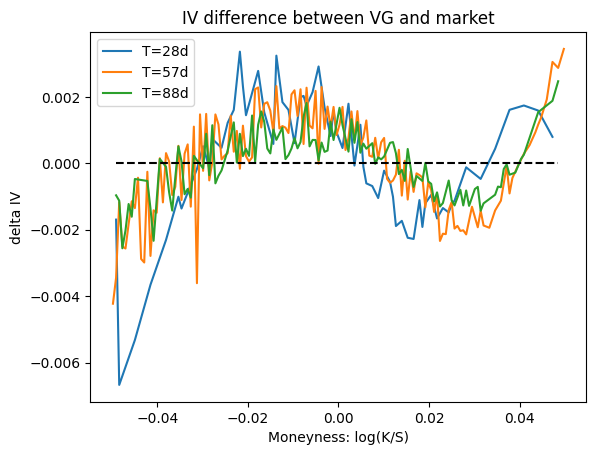

In [9]:
for j in range(len(T)):
    params= x[j]
    df = df_filtered_tot[j]
    T_i = T[j]
    iv_VG = []
    k, C = C_ITM(r, T_i, N, 1, params, eta, alpha, phi_VG)
    mask = (k > -0.5) & (k < 0.5)
    cs = CubicSpline(k[mask], C[mask])

    for i in df['strike']:
        k_target = np.log(i / S)
        price_VG = cs(k_target)
        try:
            iv = brentq(lambda sv: BS_call(1, i/S, r, T_i, sv) - price_VG, 1e-6, 5.0)
        except:
            iv = np.nan
        iv_VG.append(iv)
        
    plt.plot(df['log(K/S)'], iv_VG - df['iv_market'], label=f'T={round(T_i*365)}d')

plt.plot(df['log(K/S)'], np.zeros(len(df['log(K/S)'])), linestyle='--', color='black')
plt.legend()
plt.xlabel('Moneyness: log(K/S)')
plt.ylabel('delta IV')
plt.title('IV difference between VG and market')
plt.show()

# Heston Option pricing via Carr-Madan FFT #

We now turn to the Heston (1993) stochastic volatility model. Unlike the Variance Gamma model, which is a pure-jump process, Heston models volatility as a mean-reverting diffusion (CIR process):

$$
dS_t = rS_t dt + \sqrt{V_t} S_t dW_t^S
$$

$$
dV_t = \kappa(\eta - V_t)dt + \lambda \sqrt{V_t} dW_t^V
$$

$$
dW_t^S dW_t^V = \rho \, dt
$$

**Why Heston over VG?**

The VG model captures skewness and excess kurtosis through a stochastic time-change, but its parameters are constant — it cannot reproduce the term structure of implied volatility across maturities with a single calibration. Heston's mean-reverting variance process naturally generates a realistic term structure: short-dated smiles are steeper, long-dated smiles are flatter, consistent with what we observe in the SPX surface.

## 1.Note on numerical stability

The standard Heston characteristic function $\phi_1$ suffers from branch-cut discontinuities when numerically integrated, leading to oscillations in the FFT output. We use the $\phi_2$ formulation (Albrecher et al. 2007) which avoids this issue by ensuring continuity of the complex logarithm:

$$
\phi_2(u,t) = \exp \left(iu[\log(S_0)+(r-q)t]\right)\exp \left(\frac{\eta\kappa}{\lambda^2} \left[(\kappa-\rho\lambda iu - d)t - 2\log(\frac{1-g_2e^{-dt}}{1-g_2})\right]\right) \exp \left(\frac{\nu_0^2}{\lambda^2} \left[\kappa-\rho\lambda iu - d\right]\frac{1-e^{-dt}}{1-g_2e^{-dt}}\right)
$$

with: 
$$
g_2 = \frac{\kappa-\rho\lambda iu - d}{\kappa-\rho\lambda iu + d}, \quad d=\sqrt{(\rho\lambda ui - \kappa)^2 + \lambda^2(iu + u^2)}
$$

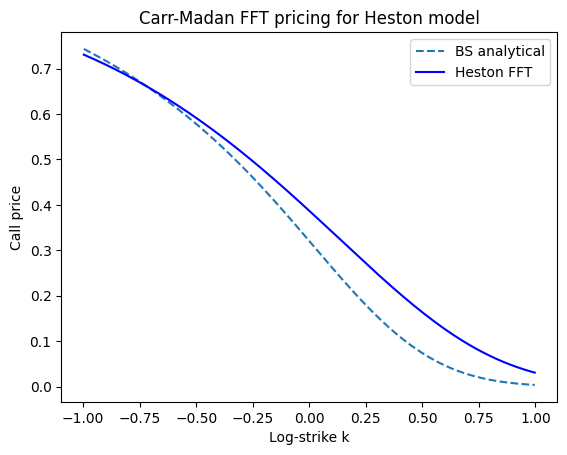

In [3]:
def phi_heston(r, T, S_0, params, u):
    eta, kappa, lambda_1, rho, nu_0 = params
    d = np.sqrt((rho*lambda_1*u*1j - kappa)**2 + lambda_1**2*(u*1j + u**2))
    g_2 = (kappa - rho*lambda_1*u*1j - d)/(kappa - rho*lambda_1*u*1j + d)
    return np.exp(1j*u*(np.log(S_0) + r*T))*np.exp(eta*kappa/lambda_1**2*((kappa - rho*lambda_1*u*1j - d)*T - 2*np.log((1-g_2*np.exp(-d*T))/(1-g_2))))*np.exp(nu_0**2/lambda_1**2*(kappa - rho*lambda_1*u*1j - d)*(1-np.exp(-d*T))/(1-g_2*np.exp(-d*T)))

params_heston = [0.0398, 1.5768, 0.5751, -0.5711, 0.0175**0.5]

k, C_heston = C_ITM(r, 10, N, S_0, params_heston, eta, alpha, phi_heston)

mask = (k >= -1) & (k <= 1)

BS_prices_1 = BS_call(S_0, np.exp(k[mask]), r, 10, params_BSM[0])
plt.plot(k_BSM[mask], BS_prices_1, label='BS analytical', linestyle='--')
plt.plot(k[mask], C_heston[mask], label='Heston FFT', color = 'blue')
plt.xlabel('Log-strike k')
plt.ylabel('Call price')
plt.title('Carr-Madan FFT pricing for Heston model')
plt.legend()
plt.show()

## 2. Heston Calibration for each maturity
Per-maturity calibration minimizing IV RMSE. L-BFGS-B optimizer with multiple starting points to avoid local minima.

**Parallelisation**

As before, each starting point in `x0_candidates_heston` leads to an independent optimisation problem. We parallelise across starting points using `joblib`, then retain the solution with the lowest RMSE. For the future historical backtest, parallelisation will be instead done across trading days, each day being an independent calibration problem.

In [30]:
from joblib import Parallel, delayed
from scipy.optimize import minimize

def optimise_single(x0, T_i, df_i):
    return minimize(
        make_ivrmse(T_i, df_i, phi_heston),
        x0,
        method='L-BFGS-B',
        bounds=bounds_heston
    )

bounds_heston = [(0.001, 0.5), (0.1, 10), (0.01, 2), (-0.99, 0), (0.01, 1)]

x0_candidates_heston = [
    [0.04, 1.5, 0.5, -0.7, 0.15],
    [0.06, 2.0, 0.3, -0.5, 0.20],
    [0.03, 1.0, 0.8, -0.9, 0.12],
]

x_parallel = []

for T_i, df_i in zip([T_30d, T_60d, T_90d], [df_filtered_30d, df_filtered_60d, df_filtered_90d]):
    results = Parallel(n_jobs=-1)(delayed(optimise_single)(x0, T_i, df_i) for x0 in x0_candidates_heston)
    result = min(results, key=lambda r: r.fun)
    x_parallel.append(result.x)

    print(T_i, result.x, result.fun)

0.07671232876712329 [ 0.38250025  1.97293148  1.9247256  -0.50924556  0.03729656] 0.001506861470584373
0.15616438356164383 [ 0.33965876  1.16505362  1.4252098  -0.54026752  0.05304251] 0.0005842401972894221
0.2410958904109589 [ 0.11961024  1.92629498  1.20285224 -0.51672107  0.11095691] 0.00044254340170504655


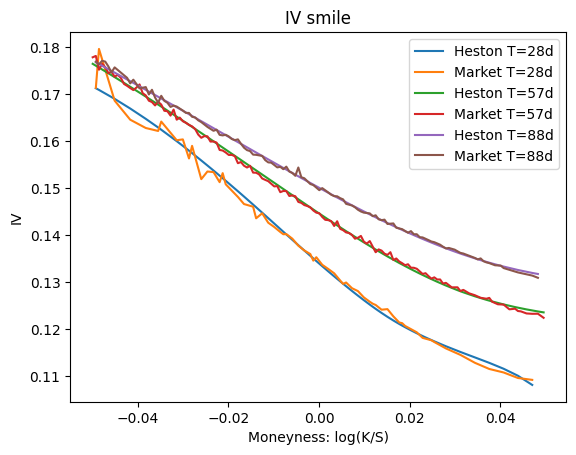

In [25]:
for j in range(len(T)):
    params = x_parallel[j]
    df = df_filtered_tot[j]
    T_i = T[j]
    iv_heston = []
    k, C = C_ITM(r, T_i, N, 1, params, eta, alpha, phi_heston)
    mask = (k > -0.5) & (k < 0.5)
    cs = CubicSpline(k[mask], C[mask])

    for i in df['strike']:
        k_target = np.log(i / S)
        price = cs(k_target)
        try:
            iv = brentq(lambda sv: BS_call(1, i/S, r, T_i, sv) - price, 1e-6, 5.0)
        except:
            iv = np.nan
        iv_heston.append(iv)

    plt.plot(df['log(K/S)'], iv_heston, label=f'Heston T={round(T_i*365)}d')
    plt.plot(df['log(K/S)'], df['iv_market'], label=f'Market T={round(T_i*365)}d')

plt.legend()
plt.xlabel('Moneyness: log(K/S)')
plt.ylabel('IV')
plt.title('IV smile')
plt.show()

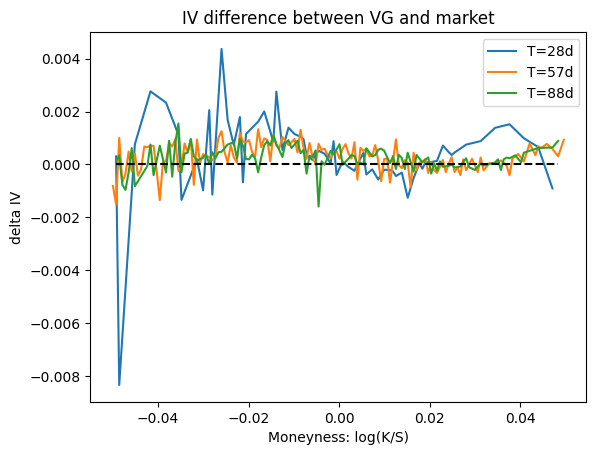

In [ ]:
for j in range(len(T)):
    params= x[j]
    df = df_filtered_tot[j]
    T_i = T[j]
    iv_heston = []
    k, C = C_ITM(r, T_i, N, 1, params, eta, alpha, phi_heston)
    mask = (k > -0.5) & (k < 0.5)
    cs = CubicSpline(k[mask], C[mask])

    for i in df['strike']:
        k_target = np.log(i / S)
        price = cs(k_target)
        try:
            iv = brentq(lambda sv: BS_call(1, i/S, r, T_i, sv) - price, 1e-6, 5.0)
        except:
            iv = np.nan
        iv_heston.append(iv)
        
    plt.plot(df['log(K/S)'], iv_heston - df['iv_market'], label=f'T={round(T_i*365)}d')

plt.plot(df['log(K/S)'], np.zeros(len(df['log(K/S)'])), linestyle='--', color='black')
plt.legend()
plt.xlabel('Moneyness: log(K/S)')
plt.ylabel('delta IV')
plt.title('IV difference between Heston and market when optimizing parameters for each maturity')
plt.show()

## 3. General Heston Calibration across all maturities
Calibration minimizing IV RMSE. L-BFGS-B optimizer with multiple starting points to avoid local minima.

**Parallelisation**

As before, we use parallelisation to gain execution time. 

In [27]:
from joblib import Parallel, delayed
from scipy.optimize import minimize

def ivrmse_joint(params):
    total = 0
    for T_i, df_i in zip(T, df_filtered_tot):
        total += make_ivrmse(T_i, df_i, phi_heston)(params)**2
    return np.sqrt(total / len(T))

def optimise_joint(x0):
    return minimize(
        ivrmse_joint,
        x0,
        method='L-BFGS-B',
        bounds=bounds_heston
    )

x0_candidates_heston = [
    [0.04, 1.5, 0.5, -0.7, 0.15],
    [0.06, 2.0, 0.3, -0.5, 0.20],
    [0.03, 1.0, 0.8, -0.9, 0.12],
]


results = Parallel(n_jobs=-1)(delayed(optimise_joint)(x0) for x0 in x0_candidates_heston)
result = min(results, key=lambda r: r.fun)

print(result.x, result.fun)

[ 0.08093238  1.98654448  1.20338673 -0.50057064  0.15368749] 0.001569610994474883


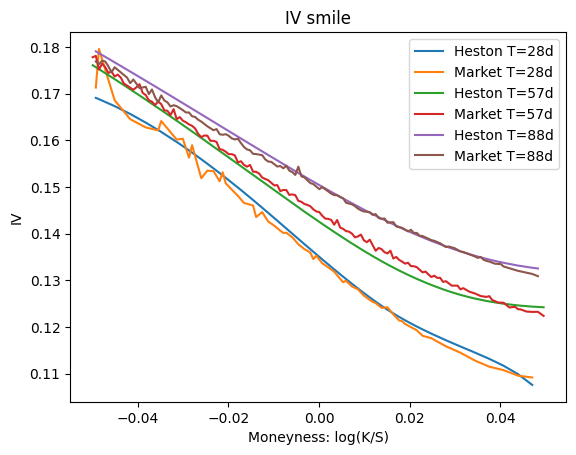

In [28]:
for j in range(len(T)):
    params = result.x
    df = df_filtered_tot[j]
    T_i = T[j]
    iv_heston = []
    k, C = C_ITM(r, T_i, N, 1, params, eta, alpha, phi_heston)
    mask = (k > -0.5) & (k < 0.5)
    cs = CubicSpline(k[mask], C[mask])

    for i in df['strike']:
        k_target = np.log(i / S)
        price = cs(k_target)
        try:
            iv = brentq(lambda sv: BS_call(1, i/S, r, T_i, sv) - price, 1e-6, 5.0)
        except:
            iv = np.nan
        iv_heston.append(iv)

    plt.plot(df['log(K/S)'], iv_heston, label=f'Heston T={round(T_i*365)}d')
    plt.plot(df['log(K/S)'], df['iv_market'], label=f'Market T={round(T_i*365)}d')

plt.legend()
plt.xlabel('Moneyness: log(K/S)')
plt.ylabel('IV')
plt.title('IV smile')
plt.show()

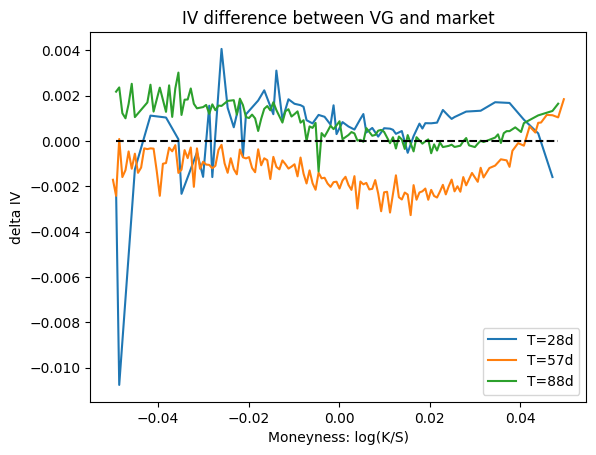

In [ ]:
for j in range(len(T)):
    params= result.x
    df = df_filtered_tot[j]
    T_i = T[j]
    iv_heston = []
    k, C = C_ITM(r, T_i, N, 1, params, eta, alpha, phi_heston)
    mask = (k > -0.5) & (k < 0.5)
    cs = CubicSpline(k[mask], C[mask])

    for i in df['strike']:
        k_target = np.log(i / S)
        price = cs(k_target)
        try:
            iv = brentq(lambda sv: BS_call(1, i/S, r, T_i, sv) - price, 1e-6, 5.0)
        except:
            iv = np.nan
        iv_heston.append(iv)
        
    plt.plot(df['log(K/S)'], iv_heston - df['iv_market'], label=f'T={round(T_i*365)}d')

plt.plot(df['log(K/S)'], np.zeros(len(df['log(K/S)'])), linestyle='--', color='black')
plt.legend()
plt.xlabel('Moneyness: log(K/S)')
plt.ylabel('delta IV')
plt.title('IV difference between Heston and market when optimizing parameters across all maturities')
plt.show()

## 4. Discussion

The residual errors are small ($RMSE < 0.1\%$) and concentrated at the wings of the smile, where liquidity is lower and bid-ask spreads are wider. This is expected: the Heston model is known to underfit deep OTM options due to its Gaussian diffusion component, which produces tails that are too thin compared to the market.

The fit is visibly better under per-maturity calibration than joint calibration, at the cost of consistency across maturities. For trading applications, the joint calibration is preferred as it produces a single arbitrage-free surface.

# Backtesting #

## 1. Using Massive API to fetch Historical data ##

Used Massive API to access option historical data. The data was saved in a csv file using `fetch_data.py` to avoid the lengthy API calls needed to collect enough data for the backtest. 

In [179]:
df_iv = pd.read_csv('df_iv.csv', parse_dates=['date'])
spx = pd.read_csv('spx.csv', index_col=0, parse_dates=True).squeeze()
df_iv.rename(columns={'iv': 'iv_market'}, inplace=True)
df_iv.head()

,date,expiry,T,S,strike,cp,price,iv_market,log(K/S)
0,2026-01-02,260918,0.709589,6858.470215,4000.0,P,23.20,0.373282,-0.539190
1,2026-01-02,260918,0.709589,6858.470215,4250.0,P,28.10,0.350739,-0.478565
2,2026-01-02,260918,0.709589,6858.470215,4500.0,P,34.10,0.329207,-0.421407
3,2026-01-02,260918,0.709589,6858.470215,4700.0,P,41.31,0.315063,-0.377922
4,2026-01-02,260918,0.709589,6858.470215,4800.0,P,43.50,0.305043,-0.356868


## 2. Joint vs per-maturity calibration

For the backtest, we calibrate a single set of Heston parameters jointly across all available maturities each day. This is more realistic than per-maturity calibration: in practice, a model used for trading must produce consistent prices across the entire surface, not just fit each slice independently. The cost is a higher RMSE — one parameter set must explain multiple maturities simultaneously. We use parallelisation on the trading days to increase the execution speed of the backtest. 

In [ ]:
from joblib import Parallel, delayed
from scipy.optimize import minimize, brentq
from scipy.interpolate import CubicSpline

available_day = np.sort(df_iv['date'].unique())

def make_ivrmse(S_i, T_i, df_i, phi):
    def ivrmse(params):
        iv_heston = []
        k, C = C_ITM(r, T_i, N, 1, params, eta, alpha, phi)
        mask = (k > -0.5) & (k < 0.5) & np.isfinite(C)
                
        if mask.sum() < 4:
            return 1.0
        
        cs = CubicSpline(k[mask], C[mask])

        for i in df_i['strike']:
            k_target = np.log(i / S_i)
            price = cs(k_target)
            try:
                iv = brentq(lambda sv: BS_call(1, i/S_i, r, T_i, sv) - price, 1e-6, 5.0)
            except:
                iv = np.nan
            iv_heston.append(iv)

        diff = np.array(iv_heston) - np.array(df_i['iv_market'])
        return np.sqrt(np.nanmean(diff**2))
    return ivrmse

bounds_heston = [(0.001, 0.5), (0.1, 10), (0.01, 5), (-0.99, 0.99), (0.01, 1)]

def make_ivrmse_backtest(S, T, df):
    def ivrmse_joint_backtest(params):
        total = 0
        for T_i in T:
            df_i = df[df['T'] == T_i].copy()
            total += make_ivrmse(S, T_i, df_i, phi_heston)(params)**2
        return np.sqrt(total / len(T))
    return ivrmse_joint_backtest

def optimise_backtest(x0, S, T, df):
    return minimize(
        make_ivrmse_backtest(S, T, df),
        x0,
        method='L-BFGS-B',
        bounds=bounds_heston
    )

x0_candidates_heston = [
    [0.04, 1.5, 0.5,  -0.7, 0.15],
    [0.06, 2.0, 0.3,  -0.5, 0.20],
    [0.03, 1.0, 0.8,  -0.9, 0.12],
    [0.05, 1.5, 2.5,  -0.7, 0.20]]

def calibrate_day(day):
    df = df_iv[df_iv['date'] == day].copy()
    T = np.sort(df["T"].unique())
    S = spx.loc[day]
    
    results = [optimise_backtest(x0, S, T, df) for x0 in x0_candidates_heston]
    result = min(results, key=lambda r: r.fun)
    
    eta, kappa, lambda_1, rho, nu_0 = result.x
    return {'date': day, 'eta': eta, 'kappa': kappa, 'lambda_1': lambda_1,
            'rho': rho, 'nu_0': nu_0, 'rmse': result.fun}

records = Parallel(n_jobs=6)(delayed(calibrate_day)(day) for day in available_day)
df_params_2 = pd.DataFrame(records).set_index('date')
df_params_2.to_csv("df_params_2.csv", index=True)
df_params_2.head()

In [180]:
df_params = pd.read_csv('df_params.csv', parse_dates=['date'])
df_params.head()

,date,eta,kappa,lambda_1,rho,nu_0,rmse
0,2026-01-02,0.102963,0.956804,1.135716,-0.990000,0.155508,0.015043
1,2026-01-05,0.062284,1.000643,0.801399,-0.903123,0.180462,0.029820
2,2026-01-06,0.077697,2.140776,2.000000,-0.864323,0.170441,0.016810
3,2026-01-07,0.067334,1.499764,0.509945,-0.705705,0.202931,NaN
4,2026-01-08,0.085453,1.936859,1.635856,-0.990000,0.144341,0.014905


Text(0.5, 0, 'date')

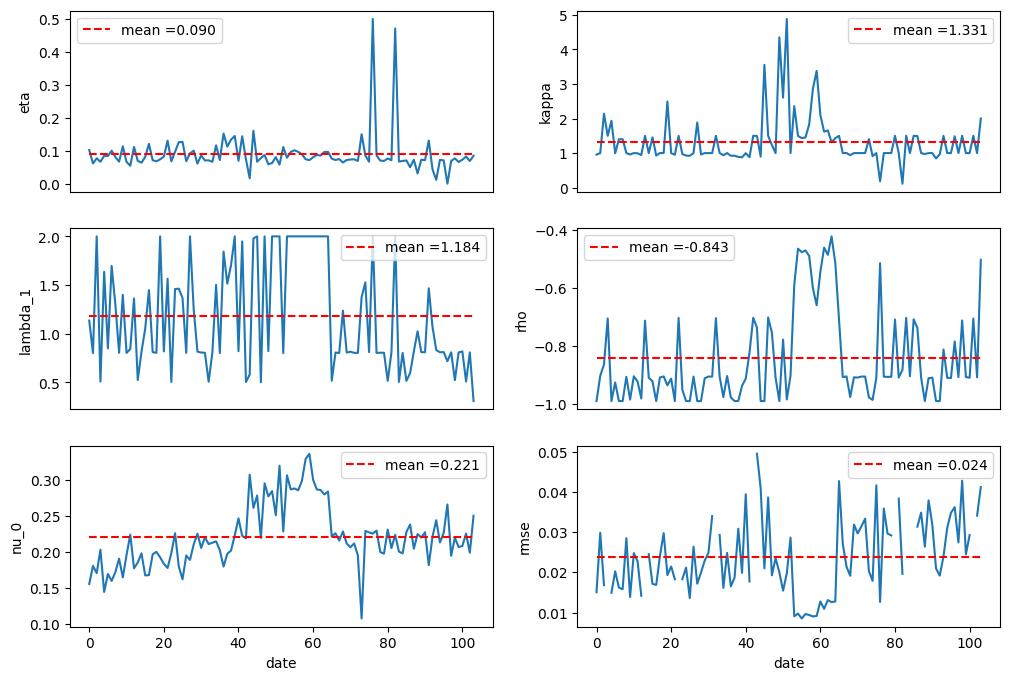

In [9]:
fig, ax = plt.subplots(3, 2, figsize=(12, 8))

parameters = ['eta', 'kappa', 'lambda_1', 'rho', 'nu_0', 'rmse']

for ii, parameter in enumerate(parameters):
    m = np.mean(df_params[parameter])
    M = m*np.ones(np.size(df_params[parameter]))
    ax[ii//2, ii%2].plot(df_params.index, df_params[parameter])
    ax[ii//2, ii%2].plot(df_params.index, M, '--', color = 'red', label = f'mean ={m:.3f}')
    ax[ii//2, ii%2].set_ylabel(parameter)
    ax[ii//2, ii%2].legend()
    if ii//2 < 2:
        ax[ii//2, ii%2].set_xticks([])

ax[2,0].set_xlabel('date')
ax[2,1].set_xlabel('date')



## 2.1 Heston Model Parameters — Temporal Analysis

### Overview
The plots above display the time evolution of the five Heston model parameters calibrated daily on SPX options data from January to June 2026, alongside the per-maturity RMSE of the implied volatility fit.

---

### Parameter-by-Parameter Analysis

**$\eta$ (eta) — Long-term variance**
Remains stable around 0.09 throughout the period, corresponding to a long-term implied volatility of approximately 30%. This is consistent with historical SPX long-term variance estimates. The absence of a structural trend suggests that the market did not significantly revise its long-run volatility expectations over the period.

**$\kappa$ (kappa) — Mean reversion speed**
Oscillates between 1 and 2 for most of the period, implying a half-life of $\frac{\ln 2}{\kappa} \approx 4$–8 months — in line with the empirical literature on SPX variance dynamics. The spikes observed in March–April 2026 are consistent with a market pricing faster mean reversion during stress episodes, as short-dated implied volatility rose sharply relative to longer maturities.

**$\lambda$ (lambda) — Volatility of variance**
Frequently hits the upper bound of 2.0, indicating that the optimizer is constrained. This parameter will be re-estimated with an expanded bound of 5.0. Note that violating the Feller condition ($2\kappa\eta > \lambda^2$) is well-documented for SPX calibrations and does not affect numerical stability under the $\phi_2$ formulation (Albrecher et al., 2007).

**$\rho$ (rho) — Spot-variance correlation**
Consistently negative, ranging from −0.7 to −1.0, reflecting the well-known leverage effect: down moves in the SPX are correlated with increases in implied volatility. The drift toward −0.5 observed in May 2026 suggests a partial attenuation of the skew following the March–April stress episode.

**$\nu_0$ (nu_0) — Initial volatility**
The most economically informative parameter on a day-to-day basis, as it captures the market's implied spot volatility. The upward trend peaking in late March–April 2026 coincides with the volatility shock triggered by U.S. tariff announcements, followed by a gradual normalisation. This parameter is expected to closely track the VIX index.

---

### Calibration Quality

The RMSE remains low throughout (≈ 0.024 on average), confirming that the Heston model provides a satisfactory fit to the SPX implied volatility surface under normal market conditions. The spikes in RMSE during April 2026 are consistent with the well-known limitation of the standard Heston model in fitting steep short-dated skews during stress episodes, where jump-diffusion models such as Bates or Merton tend to outperform.

# 3. Volatility trading strategy

## 3.1 Computing option prices and implied volatilities with Heston parameters

To get a proper vol. trading signal and to ensure no look ahead bias we computed the option prices predicted by our Heston model for each strike and maturity everyday using parameters calibrated on the same day `price_heston` and what price the model was predicting for day $t$ using parameters calibrated on day $t-1$, `price_heston_lag`, to estimate the predictive capacities of our model.

Once those prices were computed, we also computed both implied volatilies, `iv_heston` and `iv_heston_lag` since the model was optimized on volatility. 

In [234]:
for param in params:
    df_params[param + '_lag'] = df_params[param].shift(1)

df_iv['dS'] = df_iv.groupby(['strike', 'cp', 'expiry'])['S'].diff()

df_test = df_iv.merge(df_params, on='date', how='inner')
df_test = df_test.dropna()

df_test_filtered = df_test[np.abs(df_test['log(K/S)'])<= 0.5].copy()

def price_heston(S_i, T_i, K, params, cp):
    k, C = C_ITM(r, T_i, N, 1, params, eta, alpha, phi_heston)
    mask = (k > -0.5) & (k < 0.5)
    cs = CubicSpline(k[mask], C[mask])
    k_target = np.log(K / S_i)
    call_price = cs(k_target) * S_i
    if cp == 'P':
        return call_price - S_i + K * np.exp(-r * T_i)
    return call_price

df_test_filtered['price_heston'] = df_test_filtered.apply(lambda row: price_heston(row['S'], row['T'], row['strike'], [row['eta'], row['kappa'], row['lambda_1'], row['rho'], row['nu_0']], row['cp']), axis=1)
df_test_filtered['price_heston_lag'] = df_test_filtered.apply(lambda row: price_heston(row['S'], row['T'], row['strike'], [row['eta_lag'], row['kappa_lag'], row['lambda_1_lag'], row['rho_lag'], row['nu_0_lag']], row['cp']), axis=1)

df_test_filtered = df_test_filtered[(df_test_filtered['lambda_1_lag']<2) & (df_test_filtered['price_heston_lag'] >= 0)].copy()

def BS_call(S0, K, r, T, sigma):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def BS_put(S0, K, r, T, sigma):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

def IV_heston(price_heston, S, K, T, cp):
        try:
            if cp == 'C':
                iv = brentq(lambda sv: BS_call(1, K/S, r, T, sv) - price_heston/S, 1e-6, 5.0)
            else:
                 iv = brentq(lambda sv: BS_put(1, K/S, r, T, sv) - price_heston/S, 1e-6, 5.0)
        except:
            iv = np.nan
        return iv                

df_test_filtered['IV_heston'] = df_test_filtered.apply(lambda row: IV_heston(row['price_heston'], row['S'], row['strike'], row['T'], row['cp']), axis = 1)
df_test_filtered['IV_heston_lag'] = df_test_filtered.apply(lambda row: IV_heston(row['price_heston_lag'], row['S'], row['strike'], row['T'], row['cp']), axis = 1)
df_test_filtered.head()

,date,expiry,T,S,strike,cp,price,iv_market,log(K/S),dS,...,rmse,eta_lag,kappa_lag,lambda_1_lag,rho_lag,nu_0_lag,price_heston,price_heston_lag,IV_heston,IV_heston_lag
119,2026-01-05,260918,0.70137,6902.049805,4700.0,P,39.40,0.317028,-0.384256,43.57959,...,0.02982,0.102963,0.956804,1.135716,-0.99,0.155508,23.858768,36.068970,0.285940,0.311035
121,2026-01-05,260918,0.70137,6902.049805,4800.0,P,42.74,0.309093,-0.363203,43.57959,...,0.02982,0.102963,0.956804,1.135716,-0.99,0.155508,28.932136,41.346887,0.284198,0.306814
124,2026-01-05,260918,0.70137,6902.049805,5000.0,P,50.40,0.293610,-0.322381,43.57959,...,0.02982,0.102963,0.956804,1.135716,-0.99,0.155508,40.162504,52.798160,0.278359,0.296986
127,2026-01-05,260918,0.70137,6902.049805,5300.0,P,66.40,0.272930,-0.264112,43.57959,...,0.02982,0.102963,0.956804,1.135716,-0.99,0.155508,60.175332,72.549508,0.265801,0.279742
130,2026-01-05,260918,0.70137,6902.049805,5500.0,P,79.90,0.259517,-0.227070,43.57959,...,0.02982,0.102963,0.956804,1.135716,-0.99,0.155508,76.035972,87.730681,0.255752,0.267012


## 3.2 Generating the z-score

Using the implied volatilities predicted by the model we defined a simple volatility trading signal: 
$$
\text{signal}(t) = IV_{\text{heston lag}}(t) - IV_{\text{market}}(t)
$$

Once the signal was build we decided to use a z-score to limit the influence of the noise captured by our model, for this we simply use:
$$
\text{z-score}(t) = \frac{\text{signal}(t) - \text{mean}}{\text{std}}
$$
Where we used an expanding window to compute the mean and the standard deviation of the signal. To build this z-score we had to be careful to handle correctly the different strike, type of contract (call or put) and date, because the mean and std varied between different strikes.

It's also important to note that we made the choice to ignore the z-scores computed with a too small std as well as z-scores bigger than 10. 

In [235]:
df_test_filtered_2 = df_test_filtered.copy()

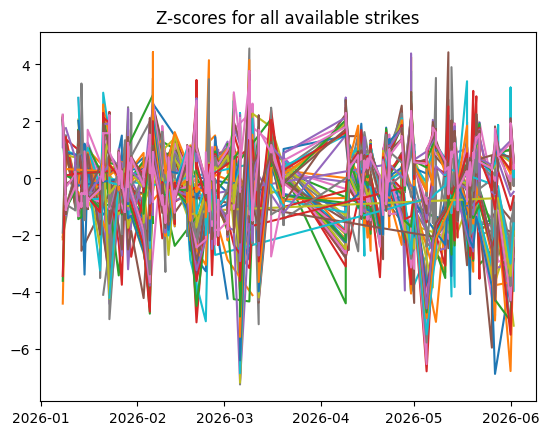

In [236]:
df_test_filtered_2['signal'] = df_test_filtered_2['IV_heston_lag'] - df_test_filtered_2['iv_market']
expanding_mean = df_test_filtered_2.groupby(['strike', 'cp', 'expiry'])['signal'].transform(lambda x: x.expanding().mean().shift(1))
expanding_std = df_test_filtered_2.groupby(['strike', 'cp', 'expiry' ])['signal'].transform(lambda x: x.expanding().std().shift(1))

df_test_filtered_2['z_score'] = (df_test_filtered_2['signal'] - expanding_mean)/expanding_std
df_test_filtered_2 = df_test_filtered_2[(expanding_std > 0.01) & (np.abs(df_test_filtered_2['z_score'])<10)].copy()

available_strikes = np.sort(df_test_filtered_2['strike'].unique())
for strike in available_strikes:
    df_strike = df_test_filtered_2[df_test_filtered_2['strike'] == strike]
    plt.plot(df_strike['date'], df_strike['z_score'])
plt.title(f'Z-scores for all available strikes')
plt.show()

## 3.3 PnL computation

Once the z-score was computed we defined a threshold to obtain a buy or sell condition for each options. If the z-score is above the threshold the market underprice volatility, we go long, our position $=+1$. Otherwise when the z-score is below the negative threshold the market overprice volatility, we short, our position $=-1$. 

To compute the PnL we simply use the formula:
$$
\text{PnL}(t) = \text{position}(t-1) \times (\text{price}(t) - \text{price}(t-1))
$$

We also compute the Sharpe ratio: 
$$
\text{Sharpe} = \frac{\text{PnL mean}}{\text{PnL std}}\times \sqrt{252}
$$

Total PnL: 5888.73
Sharpe: 4.65


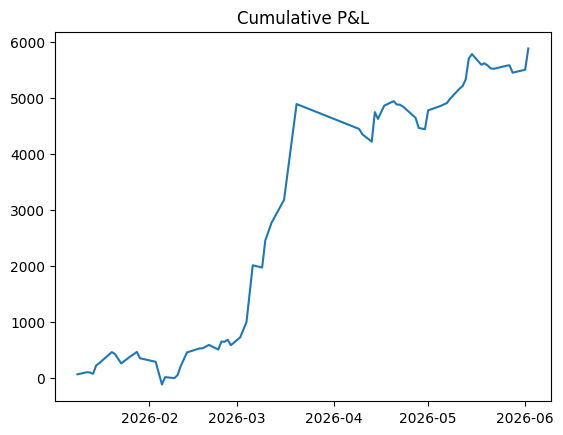

In [257]:
threshold = 1.0

df_test_filtered_2['position'] = 0
df_test_filtered_2.loc[df_test_filtered_2['z_score'] > threshold, 'position'] = 1
df_test_filtered_2.loc[df_test_filtered_2['z_score'] < -threshold, 'position'] = -1

df_test_filtered_2['return'] = df_test_filtered_2.groupby(['strike', 'cp', 'expiry'])['price'].diff()
df_test_filtered_2['position_lag'] = df_test_filtered_2.groupby(['strike', 'cp', 'expiry'])['position'].shift(1)
df_test_filtered_2['PnL'] = df_test_filtered_2['position_lag']*df_test_filtered_2['return']

PnL_tot = df_test_filtered_2['PnL'].sum()
print(f'Total PnL: {PnL_tot:.2f}')

daily_PnL = df_test_filtered_2.dropna(subset=['PnL']).groupby('date')['PnL'].sum()
sharpe = daily_PnL.mean() / daily_PnL.std() * np.sqrt(252)
print(f'Sharpe: {sharpe:.2f}')

cumPnL = daily_PnL.cumsum()
plt.plot(cumPnL)
plt.title('Cumulative P&L')
plt.show()

## 3.4 Checking the delta exposure

At first both the PnL and the Sharpe ratio seemed suspiciously high for such a simple strategy. I decided to check if the PnL was due to a high delta exposed position (if I just got lucky in the way the market evolved instead of doing proper vol. trading). To check this I computed my delta exposure as well as the PnL it was responsible of. By computing the correlation between my total PnL and the delta exposed PnL I could check wether the model was properly doing vol. trading. 

Correlation with unhedged PnL: 0.7604


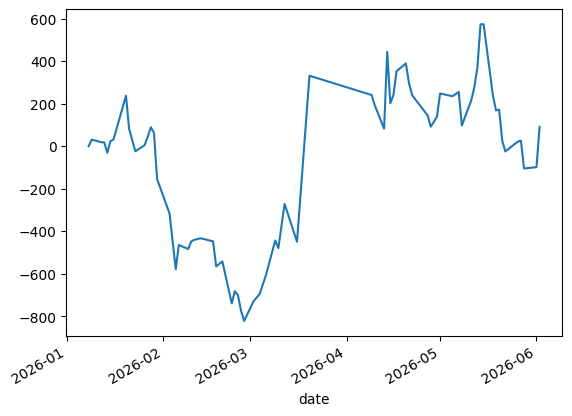

In [258]:
def delta_BS(S, K, r, T, sigma, cp):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    if cp == 'C':
        delta = norm.cdf(d1)
    else:
        delta = norm.cdf(d1) - 1
    return delta

df_test_filtered_2['delta_BS'] = df_test_filtered_2.apply(lambda row: delta_BS(row['S'], row['strike'], r, row['T'], row['iv_market'], row['cp']), axis = 1)
df_test_filtered_2['delta_BS_lag'] = df_test_filtered_2.groupby(['strike', 'cp', 'expiry'])['delta_BS'].shift(1)
df_test_filtered_2['delta_exposure'] = (df_test_filtered_2['position_lag'] * df_test_filtered_2['delta_BS_lag'])

df_test_filtered_2['delta_pnl'] = (df_test_filtered_2['position_lag'] * df_test_filtered_2['delta_BS_lag'] * df_test_filtered_2['dS'])
daily_delta_pnl = (df_test_filtered_2.groupby('date')['delta_pnl'].sum())
daily_delta_pnl.cumsum().plot()

daily_strategy_pnl = (df_test_filtered_2.groupby('date')['PnL'].sum())
corr = daily_strategy_pnl.corr(daily_delta_pnl)
print(f'Correlation with unhedged PnL: {corr:.4f}')

After correcting the groupby to account for expiry, the correlation between the unhedged strategy P&L and the delta exposure P&L is 0.8, suggesting significant directional exposure.

In [249]:
pnl_by_strike = df_test_filtered_2.groupby(['strike', 'cp', 'expiry'])['PnL'].sum().sort_values(ascending=False)
print(pnl_by_strike)

strike  cp  expiry
6600.0  C   260918    500.22
6800.0  C   260918    262.09
6850.0  C   261218    186.22
6800.0  P   260918    180.77
6700.0  P   260918    163.89
                       ...  
6950.0  P   261218    -40.34
6600.0  P   261218    -55.98
6400.0  C   260918    -58.40
6000.0  C   260320    -76.22
5000.0  C   261218   -608.21
Name: PnL, Length: 159, dtype: float64


## 3.5 Implementing Delta Hedging

We now delta-hedge our position to limit our exposure to the direction of moves in the underlying. We use the Black-Scholes delta rather than the Heston delta for two reasons: first, the P&L is dominated by near-ATM options where the two deltas are very similar; second, computing the Heston delta requires two FFT evaluations per option (numerical differentiation with respect to $S$), which is computationally expensive at scale. We use the lagged delta $\Delta_{t-1}$ to avoid lookahead bias — the hedge ratio is set at the end of day $t-1$ before observing day $t$ market data.

Total Hedged PnL: 5797.88
Hedged Sharpe: 6.64
Correlation with hedged PnL: 0.3367


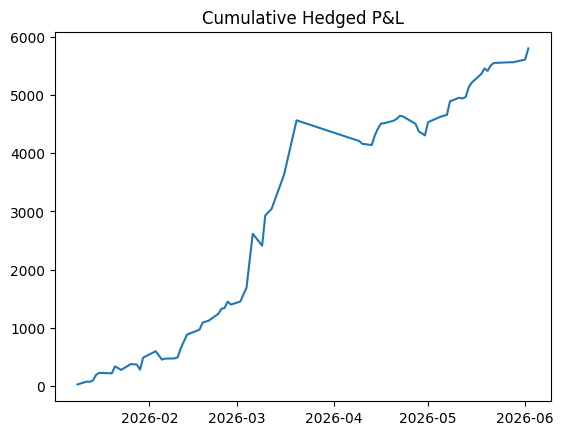

In [259]:
df_test_filtered_2['PnL_hedged'] = df_test_filtered_2['position_lag'] * (df_test_filtered_2['return'] - df_test_filtered_2['delta_BS_lag'] * df_test_filtered_2['dS'])
PnL_tot = df_test_filtered_2['PnL_hedged'].sum()

daily_PnL_hedged = df_test_filtered_2.dropna(subset=['PnL_hedged']).groupby('date')['PnL_hedged'].sum()

PnL_tot = df_test_filtered_2['PnL_hedged'].sum()
print(f'Total Hedged PnL: {PnL_tot:.2f}')

sharpe_hedged = daily_PnL_hedged.mean() / daily_PnL_hedged.std() * np.sqrt(252)
print(f'Hedged Sharpe: {sharpe_hedged:.2f}')

daily_delta_pnl = (df_test_filtered_2.groupby('date')['delta_pnl'].sum())
daily_strategy_pnl_hedged = (df_test_filtered_2.groupby('date')['PnL_hedged'].sum())
corr_hedged = daily_strategy_pnl_hedged.corr(daily_delta_pnl)
print(f'Correlation with hedged PnL: {corr_hedged:.4f}')

cumPnL_hedged = daily_PnL_hedged.cumsum()
plt.plot(cumPnL_hedged)
plt.title('Cumulative Hedged P&L')
plt.show()

After delta hedging using lagged BS delta (to avoid lookahead bias), the correlation drops to 0.34 and the Sharpe increases to 6.64, confirming that the vol signal itself has genuine edge but that the unhedged strategy was partially driven by directional exposure. A Sharpe of 6 is unrealistic in practice - the best systematic funds operate at 2-3. The most likely explanation is that we are trading at mid-price with zero transaction costs, which is not achievable in live trading. We now model the bid-ask spread to obtain a more realistic estimate.

## 3.6 Modeling Transaction Costs

The previous analysis assumed trading at mid-price with zero transaction costs, which is unrealistic in practice. We model the bid-ask spread as a fixed percentage $c$ of the option mid-price, charging half the spread on each entry and exit:

$$
\text{cost}(t) = \frac{c}{2} \times \text{price}(t-1) \times |\Delta \text{position}(t)|
$$

where $|\Delta \text{position}(t)|$ is non-zero only when the position changes, correctly reflecting that transaction costs are only incurred when trading. We run the backtest for several values of $c$ to assess the sensitivity of the strategy to transaction costs.

In [265]:
df_test_filtered_2['price_lag'] = df_test_filtered_2.groupby(['strike', 'cp' , 'expiry'])['price'].shift(1)
df_test_filtered_2[(df_test_filtered_2['strike']==6800) & (df_test_filtered_2['cp']=='C')].head()

,date,expiry,T,S,strike,cp,price,iv_market,log(K/S),dS,...,position,return,position_lag,PnL,delta_BS,delta_exposure,delta_pnl,PnL_hedged,delta_BS_lag,price_lag
651,2026-01-08,260320,0.194521,6921.459961,6800.0,C,271.90,0.145021,-0.017704,0.529785,...,1,NaN,NaN,NaN,0.662400,NaN,NaN,NaN,NaN,NaN
748,2026-01-09,261218,0.939726,6966.279785,6800.0,C,673.44,0.171912,-0.024159,44.819824,...,0,NaN,NaN,NaN,0.667384,NaN,NaN,NaN,NaN,NaN
790,2026-01-09,260320,0.191781,6966.279785,6800.0,C,309.10,0.152738,-0.024159,44.819824,...,-1,37.20,1.0,37.20,0.690955,0.662400,29.688667,7.511333,0.662400,271.90
885,2026-01-12,261218,0.931507,6977.270020,6800.0,C,682.00,0.173652,-0.025735,10.990234,...,0,8.56,0.0,0.00,0.669606,0.000000,0.000000,0.000000,0.667384,673.44
927,2026-01-12,260320,0.183562,6977.270020,6800.0,C,309.75,0.150698,-0.025735,10.990234,...,0,0.65,-1.0,-0.65,0.703307,-0.690955,-7.593757,6.943757,0.690955,309.10


In [277]:
def backtest_with_cost(df, c):
    df_backtest = df.copy()
    df_backtest['delta_position'] = df_backtest.groupby(['strike', 'cp', 'expiry'])['position_lag'].diff().abs()
    df_backtest['PnL_adjusted'] = df_backtest['PnL_hedged'] - c/2 * df_backtest['price_lag'] * np.abs(df_backtest['delta_position'])

    daily_PnL = df_backtest.dropna(subset=['PnL_adjusted']).groupby('date')['PnL_adjusted'].sum()
    sharpe = daily_PnL.mean() / daily_PnL.std() * np.sqrt(252)
    total_pnl = daily_PnL.sum()
    
    return sharpe, total_pnl

results = []
for c in [0.00, 0.01, 0.015, 0.02, 0.05, 0.10]:
    sharpe, pnl = backtest_with_cost(df_test_filtered_2, c)
    results.append({'Spread (% of mid)': f'{c:.1%}', 'Sharpe': round(sharpe, 2), 'Total PnL': round(pnl, 0)})

pd.DataFrame(results)

,Spread (% of mid),Sharpe,Total PnL
0,0.0%,6.66,5651.0
1,1.0%,2.88,2315.0
2,1.5%,0.82,648.0
3,2.0%,-1.31,-1020.0
4,5.0%,-13.39,-11027.0
5,10.0%,-23.02,-27704.0


## Conclusion

The sensitivity analysis reveals that the strategy is highly dependent on transaction costs. At 1% spread the Sharpe ratio drops from 6.66 to 2.88 — a realistic and respectable performance for a volatility strategy. Above 2% the strategy becomes unprofitable. 

For liquid near-ATM SPX options, realistic bid-ask spreads are typically 0.5–1.5% of mid-price, suggesting the strategy sits on the edge of viability in live trading. The next natural step would be to source real bid-ask data to replace the modeled spread, and to filter out illiquid strikes where transaction costs would exceed the 1% threshold.